# Drift correction tutorial - 0°/90° HAADF pair (real EMD)

A STEM scan drifts during acquisition, so a single image is sheared by sample +
stage motion. Collecting the **same area twice at orthogonal scan rotations (0° and
90°)** lets us solve that per-scanline drift: each scan smears drift along its own
fast-scan axis, so the orthogonal partner constrains what the first cannot. This
notebook walks the full pipeline on a real Velox EMD pair and explains every parameter.

All figures here come from `DriftCorrection`'s **own plotting** (`show_merged=...`,
`plot_merged_images`, `plot_warped_images`) for static PNG views, plus `Show2D` for the
interactive comparison.

**Data:** DRAM, 15.0 Mx, 6.74 nm FOV, 2048×2048 (`0041`=0°, `0042`=90°).

**Pipeline:** `read_emd_pair` → `preprocess` → `align_affine` → diagnostics → corrected merge.

## Setup

Install the two packages this tutorial needs (run once; restart the kernel if asked):

- **quantem.widget** (the `Show2D` viewer) - latest from **TestPyPI**.
- **quantem** (the drift algorithm: `read_emd_pair`, `DriftCorrection`) - from the drift branch.


In [11]:
# Install for this tutorial:
#  - quantem: from the drift branch of the bobleesj fork (read_emd_pair + DriftCorrection
#    live here; not yet in a released quantem).
#  - quantem.widget (Show2D): latest from TestPyPI.
# Restart the kernel after this cell on a fresh environment.
%pip install -q -U "quantem @ git+https://github.com/bobleesj/quantem@drift-june-2026"
%pip install -q -U -i https://test.pypi.org/simple/ --extra-index-url https://pypi.org/simple/ quantem-widget

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [12]:
%load_ext autoreload
%autoreload 2
import numpy as np
import quantem as em
from quantem.widget import Show2D, profile

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# Record the environment (versions / device) - run this at the top of every notebook.
profile()

## 1. Load the 0°/90° pair

`em.imaging.read_emd_pair(path_0, path_90)` reads both Velox EMD files and returns a
bundle. The scan rotation is read **straight from each file's `Scan.ScanRotation`
metadata** - you never type the angle. The returned `scan_direction_degrees` (here
`(0.0, 90.0)`) is exactly the form `DriftCorrection` needs to orient each scan.

- `data` - the two frames as `Dataset2d` (each carries its nm pixel size)
- `scan_direction_degrees` - per-frame scan rotation in degrees, auto-parsed
- `pixel_size_nm`, `shape` - calibration straight from the microscope

In [13]:
DATA_DIR = '/home/owner/data/dasol/20260515_dram_drift_dasol'
# DRAM 15.0 Mx, 6.74 nm FOV, 2048x2048 - 0°/90° pair (0041 = 0 deg, 0042 = 90 deg).
F0  = '0041-20260515_1130_15.0_Mx_6.74_nm_Nano_HAADF.emd'
F90 = '0042-20260515_1130_15.0_Mx_6.74_nm_Nano_HAADF.emd'

# read_emd_pair prints shape / pixel size / scan angles itself (verbose=True default).
pair = em.imaging.read_emd_pair(f'{DATA_DIR}/{F0}', f'{DATA_DIR}/{F90}')
data_0, data_1 = pair['data']

shape       = (2048, 2048)
pixel size  = 3.29 pm
scan angles = (0.0, 90.0) deg  (read from EMD)


## 2. `preprocess` - build the scanline model

`DriftCorrection.from_images(im0, im90, scan_direction_degrees=...)` creates the solver;
`preprocess` lays both scans onto a shared padded canvas and initializes the Bezier
knots that map each scanline into it. Nothing can be aligned before this.

`show_images=True` uses the built-in plotting to show **the two scans individually** (not
their merge) - this is the raw, un-aligned input you are about to drift-correct.

**Parameters**
- `pad_fraction=0.5` - canvas padding per side (50%). Bigger = more room for drift, more memory.
- `pad_value='median'` - fill outside each scan's footprint (keeps background flat).
- `kde_sigma=0.5` - Gaussian smoothing (px) after the bilinear scatter; suppresses scatter noise.
- `number_knots=1` - knots per scanline. `1` = **linear** drift per line (recommended).

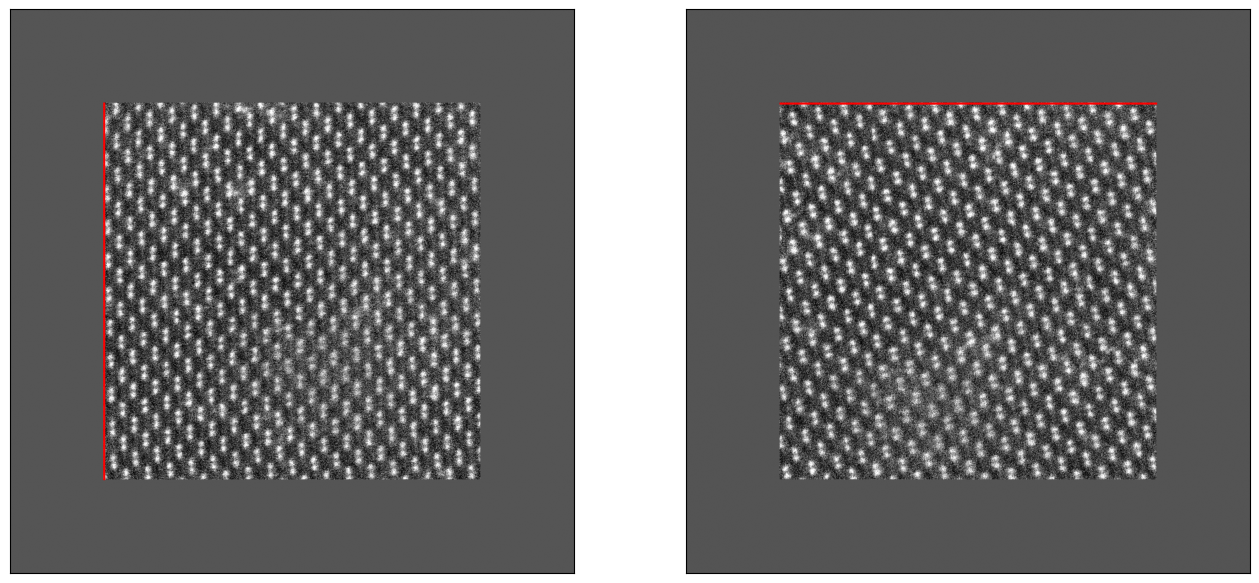

In [14]:
drift = em.imaging.DriftCorrection.from_images(
    data_0, data_1, scan_direction_degrees=pair['scan_direction_degrees'],
)
# show_images=True displays the two scans on the canvas (not their merge) so you see the raw inputs.
drift.preprocess(pad_fraction=0.5, pad_value='median', kde_sigma=0.5, number_knots=1,
                 show_images=True, show_merged=False)

## 3. `align_affine` - grid-search the per-scanline drift

Builds a grid of candidate linear-drift rates, warps both scans for each, keeps the
lowest cross-correlation cost; `refine` subdivides the winner for sub-step accuracy.
`show_merged=True` makes the class plot the corrected merge as soon as it finishes.

**Parameters**
- `step=0.02` - grid resolution in **px per scan line**.
- `num_tests=21` - rates tested per axis (odd, centered on zero). Grid spans
  `± step × (num_tests-1)/2` = **±0.20 px/line** here.
- `refine=True` - second pass at `step/(num_tests-1)` around the winner.
- `max_image_shift=512` - reject cross-correlation peaks beyond this radius (px). **Must be
  large enough for the real shift** - too small silently caps the result.

> **Grid-width rule:** `step × (num_tests-1)/2` must be ≥ the true max drift, or the search
> lands on the boundary and *undershoots*. ±0.10 was too narrow for this pair; ±0.20 recovers it.

**Readouts** (printed automatically)
- `drift_rate` - solved (row, col) drift in px/line.
- `affine_confidence_margin` - % cost gap to the runner-up candidate. Low on periodic atomic
  lattices (many near-equal candidates) - expected here, not a failure.

  affine grid: 349 cand × 3072×3072, 0.68 GB/cand → 6/chunk × 59 passes (9/102 GB free)
  Coarse search - top 5 candidates:
    drift=(-0.0800, +0.1400) px/line (0.1612 magnitude), cost=217.7850 (best)
    drift=(-0.0600, +0.1400) px/line (0.1523 magnitude), cost=220.5825 (+1.3%)
    drift=(-0.1000, +0.1400) px/line (0.1720 magnitude), cost=229.1624 (+5.2%)
    drift=(-0.0800, +0.1200) px/line (0.1442 magnitude), cost=234.8577 (+7.8%)
    drift=(-0.1000, +0.1200) px/line (0.1562 magnitude), cost=236.1812 (+8.4%)
  affine grid: 349 cand × 3072×3072, 0.68 GB/cand → 6/chunk × 59 passes (9/102 GB free)
  Refine search - top 5 candidates:
    drift=(+0.0070, -0.0010) px/line (0.0071 magnitude), cost=213.9089 (best)
    drift=(+0.0090, +0.0000) px/line (0.0090 magnitude), cost=213.9774 (+0.0%)
    drift=(+0.0070, -0.0020) px/line (0.0073 magnitude), cost=214.0242 (+0.1%)
    drift=(+0.0090, -0.0010) px/line (0.0091 magnitude), cost=214.0483 (+0.1%)
    drift=(+0.0060, -0.0020) px/line (0.006

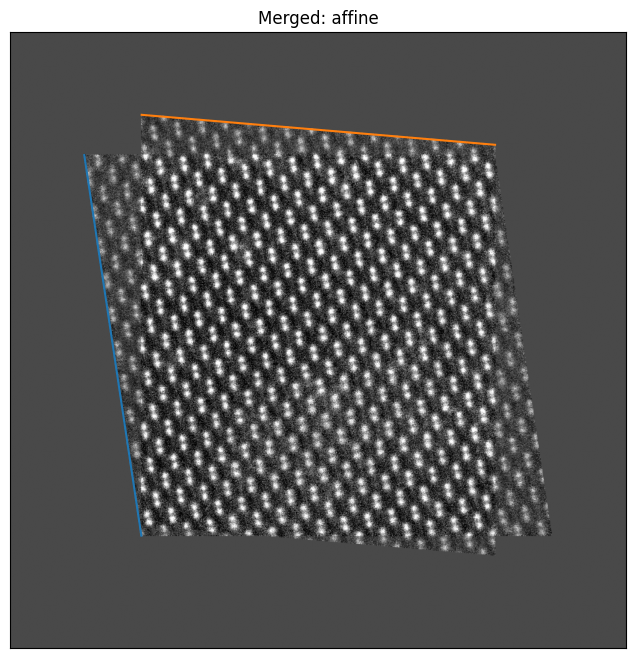

In [15]:
# align_affine prints the solved drift rate, total shift, and confidence itself.
drift.align_affine(step=0.02, num_tests=21, refine=True, max_image_shift=512, show_merged=True)

## 4. Diagnostic - RGB overlay

`align_affine(show_merged=True)` already showed the plain corrected merge, so the only
extra view worth one cell is the RGB overlay: the two corrected scans go in separate
color channels - **agreement is gray, any residual offset shows as colored fringes**.

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Merged (RGB overlay)'}>)

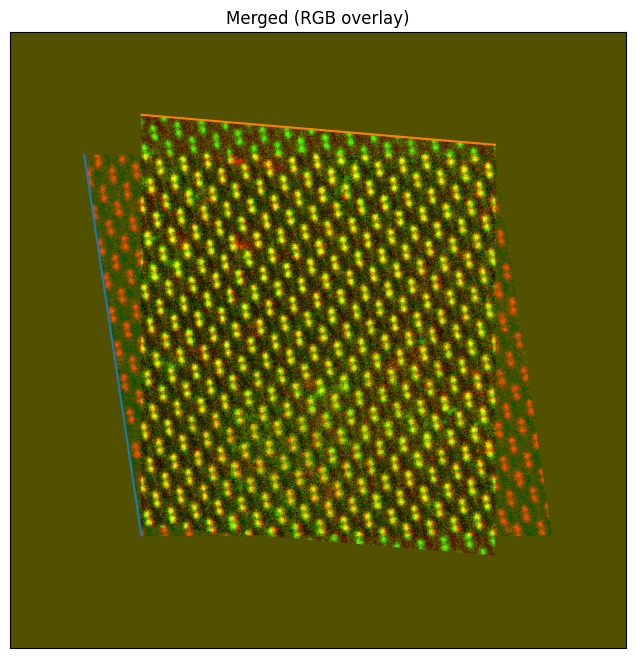

In [16]:
drift.plot_merged_images(axsize=(8, 8), rgb=True)

## 5. Corrected merge - interactive

`generate_corrected` warps both scans with the solved drift and averages them into a
single drift-free image. `Show2D` puts raw 0°, raw 90°, and the corrected merge side by
side, **zoomed 3× with a calibrated scale bar** (the nm/px pixel size comes straight from
the EMD), with shared pan / zoom / contrast in the browser.

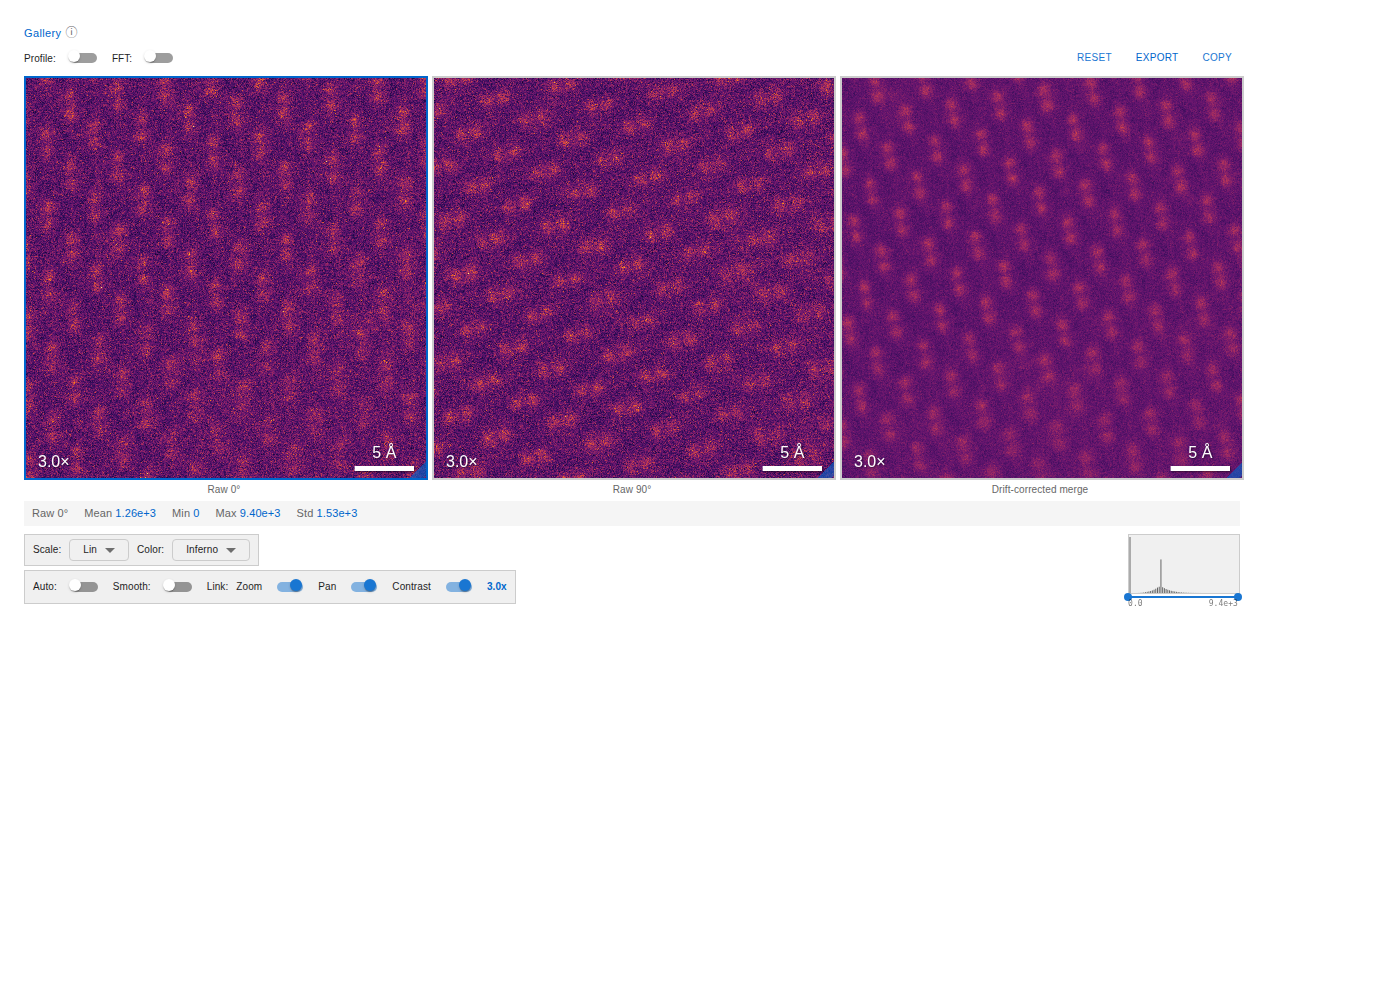

In [17]:
image_corr = drift.generate_corrected(show_merged=False)
Show2D(
    [data_0.array, data_1.array, image_corr.array],
    labels=['Raw 0°', 'Raw 90°', 'Drift-corrected merge'],
    sampling=pair['pixel_size_nm'],   # nm/px from the EMD, so the scale bar is correct
    units='nm',
    ncols=3,                          # 3 panels across
    size=400,                         # 400 px per panel
    zoom=3.0,
    offline=True,
    link_contrast=False,             # per-panel contrast: raw and corrected have different ranges                         # 3x magnification built in
)

## 6. Save the corrected merge

Save the drift-corrected image as a `.npy` so it can be reopened later without re-running
the whole pipeline.

In [18]:
from pathlib import Path
save_dir = Path('outputs'); save_dir.mkdir(exist_ok=True)
out = save_dir / 'drift_dram_15mx_0041_0042_merged.npy'
np.save(out, image_corr.array)
print(f'saved {out}  shape={image_corr.array.shape}  dtype={image_corr.array.dtype}')

saved outputs/drift_dasol_15Mx_0041_0042_merged.npy  shape=(3072, 3072)  dtype=float32


## 7. Open the corrected image later (no re-run needed)

Once the merge is saved you can view it on its own - in a notebook with `Show2D`, or
straight from the terminal with the `quantem` CLI.

**In a notebook:** load the `.npy` and hand it to `Show2D` (calibrated scale bar via
`sampling`).

**From the terminal (no notebook):**
```bash
quantem show2d outputs/drift_dram_15mx_0041_0042_merged.npy   # -> Show2D HTML, opens in browser
```
`quantem show2d` renders any image file to a standalone, offline HTML viewer.

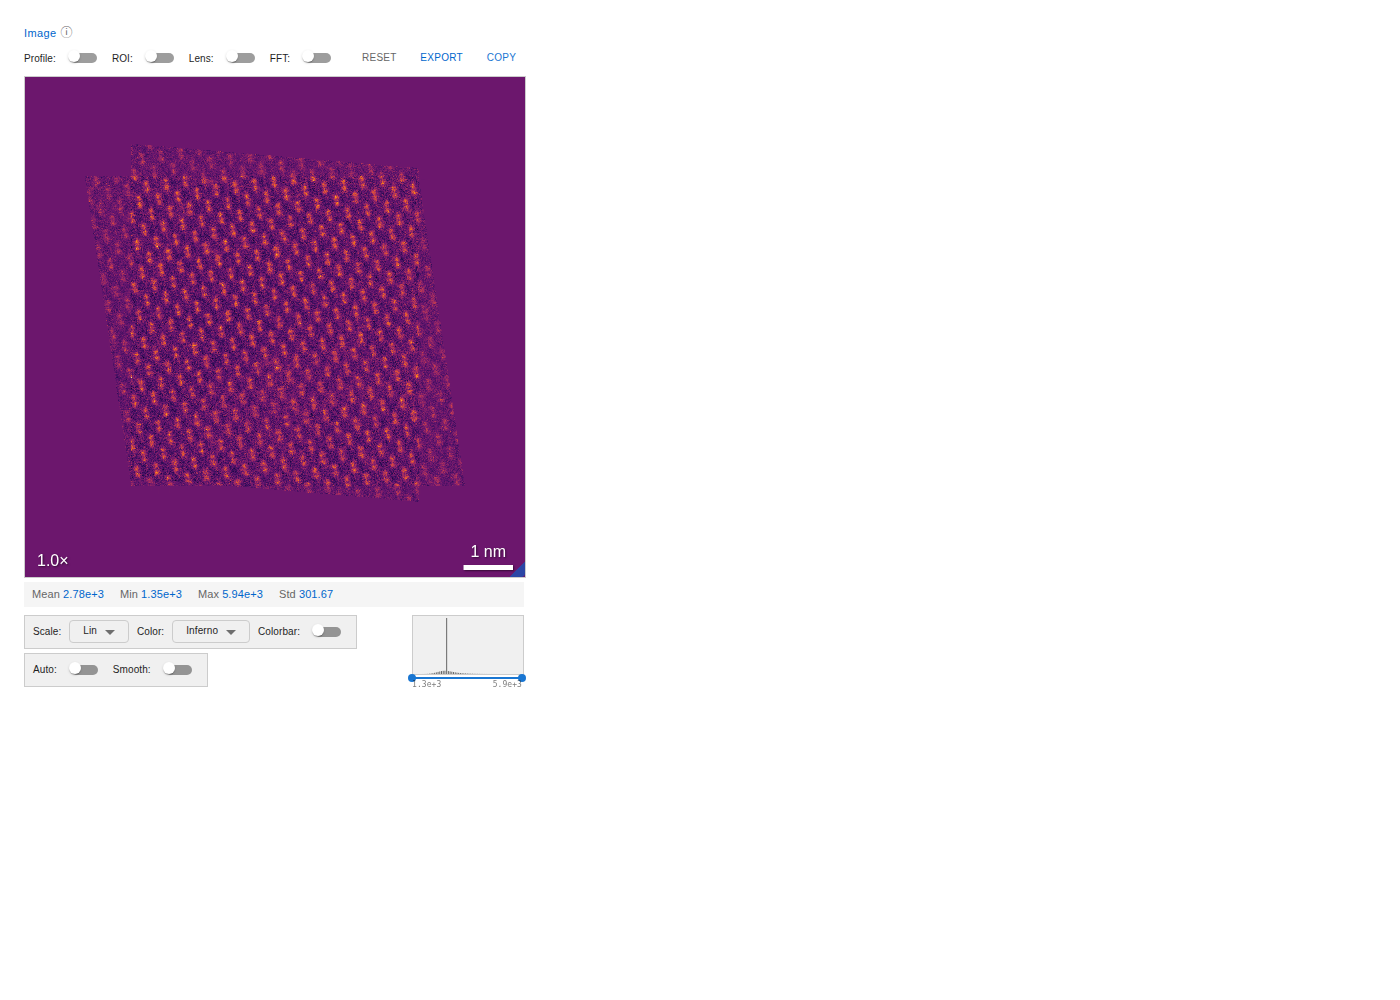

In [19]:
merged = np.load('outputs/drift_dram_15mx_0041_0042_merged.npy')
Show2D(merged, labels=['Drift-corrected merge'], sampling=pair['pixel_size_nm'], units='nm', size=500, offline=True)

## 8. Export this tutorial to a shareable HTML

Run all cells and save, then produce a standalone HTML (rendered figures + the Show2D
panels as static images) that opens in any browser with no Python or kernel - send it
alongside the `.ipynb`. Use the `quantem` CLI (installed with the widget):

```bash
quantem html drift_dram_mag_15mx.ipynb            # execute + bake -> offline HTML
quantem html drift_dram_mag_15mx.ipynb --no-execute   # just wrap the already-run outputs
```
(Equivalent raw tool: `jupyter nbconvert --to html --execute drift_dram_mag_15mx.ipynb`.)
The cell below runs it from inside the notebook.

In [20]:
# Export this already-run notebook to a standalone HTML via the quantem CLI.
!quantem html drift_dram_mag_15mx.ipynb --no-execute

usage: quantem [-h] {show,show2d,show3d,show4dstem} ...
quantem: error: argument command: invalid choice: 'html' (choose from show, show2d, show3d, show4dstem)
